# Slack-weight sweep — reach-avoid funnel vs `slack_weight` (dubins)

For the reduced single-integrator system $\dot{\bm y}=k_1(\bm y)$, the per-sample slack
SOP returns a descent slack $\delta$ and a fixed backstepping scale $\lambda$. The
**certified reach-avoid funnel** is

$$\mathcal F=\{\,\bm y\in\mathcal X_S\setminus\mathcal X_T:\ \psi(\bm y):=\mathrm{safe}(\bm y)\ \ge\ \delta/\lambda\,\},$$

because along the flow $\dot\psi=\nabla\mathrm{safe}\cdot k_1\ \ge\ \lambda\,\mathrm{safe}-\delta$,
which is positive (barrier grows $\Rightarrow$ trajectory driven into $\mathcal X_T$ while
staying safe) **only where** $\mathrm{safe}>\delta/\lambda$. A large $\delta/\lambda$ shrinks
— and once it exceeds $\max\mathrm{safe}$, **empties** — that funnel.

This notebook sweeps `slack_weight` and, using a **dense sample of $\mathcal X_S\setminus\mathcal X_T$**,
(i) visualizes how the certified feasible region changes, (ii) plots the funnel fraction and
$\delta/\lambda$ vs `slack_weight`, and (iii) compares the slacks across configurations.

Self-contained: triggers `sweep_slack_weight_dubins.m` (frozen toolchain) only if the sweep
CSV is missing, and reads/writes only `revision/data/`.


## §1 — Bootstrap: sets, dense $\mathcal X_S\setminus\mathcal X_T$ sample, MATLAB runner


In [1]:
import importlib.util, json, os, shutil, subprocess, sys, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# locate ROOT via revision/matlab_frozen (no main-repo dependency)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
FROZEN = os.path.join(REV, "matlab_frozen")
SDIR = os.path.join(REV, "slack_diagnostic")
DATA = os.path.join(REV, "data")
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"


def run_matlab(script_name, env=None):
    """Run a slack_diagnostic MATLAB driver (frozen + slack_diagnostic on path)."""
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{FROZEN}'); addpath('{SDIR}'); "
        f"try, {script_name}; catch e, disp(getReport(e)); exit(1); end; exit(0);",
    ]
    e = dict(os.environ)
    if env:
        e.update({k: str(v) for k, v in env.items()})
    t0 = time.time()
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=e,
    )
    for raw in proc.stdout:
        line = raw.rstrip()
        if any(
            s in line
            for s in ("sweep_slack", "[w=", "[vanilla", "valid", "wrote", "rror")
        ):
            print(f"[matlab +{time.time() - t0:5.0f}s] {line}")
            sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"MATLAB {script_name} failed (rc={proc.returncode})")


# dubins safe/target sets in OUTPUT coords y=(y1,y2) (frozen example def; self-contained)
y1, y2 = sp.symbols("y1 y2")
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_y = (y2) ** 2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4
safe_y = 1e-3 * (-target_y + 300) * h_raw
safe_f = sp.lambdify((y1, y2), safe_y, "numpy")
targ_f = sp.lambdify((y1, y2), target_y, "numpy")

# dense sample of X_S\X_T (safe >= 0 AND outside target) in output space
N = 1_000_000
LO, HI = -2.2, 2.2
rng = np.random.default_rng(0)
Yall = rng.uniform(LO, HI, size=(2, N))
sv = np.asarray(safe_f(Yall[0], Yall[1]), float)
tv = np.asarray(targ_f(Yall[0], Yall[1]), float)
in_set = (sv >= 0) & (tv > 0)
Yin = Yall[:, in_set]  # (2, n_in) output coords inside X_S\X_T
safe_in = sv[in_set]  # safe(y) at those points
safe_max = float(safe_in.max())

# fine grid for set-boundary contours
gg = np.linspace(LO, HI, 400)
G1, G2 = np.meshgrid(gg, gg)
Zs = np.asarray(safe_f(G1, G2), float)
Zt = np.asarray(targ_f(G1, G2), float)

print(
    f"dense X_S\\X_T: {safe_in.size:,} / {N:,} in set;  safe range [{safe_in.min():.3g}, {safe_max:.3g}]"
)
print(f"=> certified funnel is EMPTY whenever delta/lambda > max safe = {safe_max:.3g}")

dense X_S\X_T: 351,279 / 1,000,000 in set;  safe range [1.87e-05, 10.8]
=> certified funnel is EMPTY whenever delta/lambda > max safe = 10.8


## §2 — Slack-weight sweep ($\delta,\lambda$ per weight + vanilla reference)


In [2]:
# sweep_slack_weight_dubins.m re-solves the per-sample slack SOP over a list of
# slack_weights (one system build + one sample set), recording delta/lambda for each,
# plus the vanilla (no per-sample constraints) reference row. Full sweep ~12 min.
REGENERATE = False
SLACK_WEIGHTS = None  # e.g. "1,0.1,0.01,1e-3,1e-4,1e-5,1e-6" to override the .m default
SWEEP_CSV = os.path.join(DATA, "slack_weight_sweep_dubins.csv")

if REGENERATE or not os.path.exists(SWEEP_CSV):
    print(
        "running sweep_slack_weight_dubins.m (MATLAB) -- ~12 min, live stage output ..."
    )
    run_matlab(
        "sweep_slack_weight_dubins",
        env=({"SLACK_WEIGHTS": SLACK_WEIGHTS} if SLACK_WEIGHTS else None),
    )
else:
    print(
        f"using cached {os.path.relpath(SWEEP_CSV, ROOT)}  (set REGENERATE=True to re-run)"
    )

df = pd.read_csv(SWEEP_CSV)
df["delta_over_lambda"] = df["delta"] / df["lambda"]
df["label"] = df["slack_weight"].map(lambda w: "vanilla" if pd.isna(w) else f"{w:g}")
df["funnel_pct"] = [
    100.0 * float(np.mean(safe_in >= t)) for t in df["delta_over_lambda"]
]
df[
    [
        "label",
        "delta",
        "lambda",
        "delta_over_lambda",
        "funnel_pct",
        "slack1_max",
        "slack2_max",
    ]
]

using cached revision/data/slack_weight_sweep_dubins.csv  (set REGENERATE=True to re-run)


,label,delta,lambda,delta_over_lambda,funnel_pct,slack1_max,slack2_max
0,vanilla,1.503135e-10,1.094563e-08,1.373274e-02,99.921715,0.000000,0.000000
1,1,9.218548e-01,1.094563e-08,8.422126e+07,0.000000,33.715084,3.219441
2,0.1,5.664291e-02,1.094563e-08,5.174933e+06,0.000000,33.743984,3.222599
3,0.01,7.814196e-08,1.094563e-08,7.139100e+00,50.509993,33.738831,3.221399
4,0.001,7.711305e-10,1.094563e-08,7.045099e-02,99.592631,33.738838,3.221403
5,0.0001,4.480813e-09,1.094563e-08,4.093700e-01,97.606176,33.738878,3.221486
6,1e-05,6.143029e-10,1.094563e-08,5.612311e-02,99.672340,33.739023,3.221534
7,1e-06,-2.201273e-10,1.094563e-08,-2.011097e-02,100.000000,33.762083,3.235048


## §3 — Reach-avoid funnel per `slack_weight` (dense sampling)

Dense $\mathcal X_S\setminus\mathcal X_T$ points coloured by membership in
$\{\mathrm{safe}\ge\delta/\lambda\}$: **blue = certified reach-avoid funnel**, grey = excluded.
The black curve is the safe-set boundary, the red curve the target.


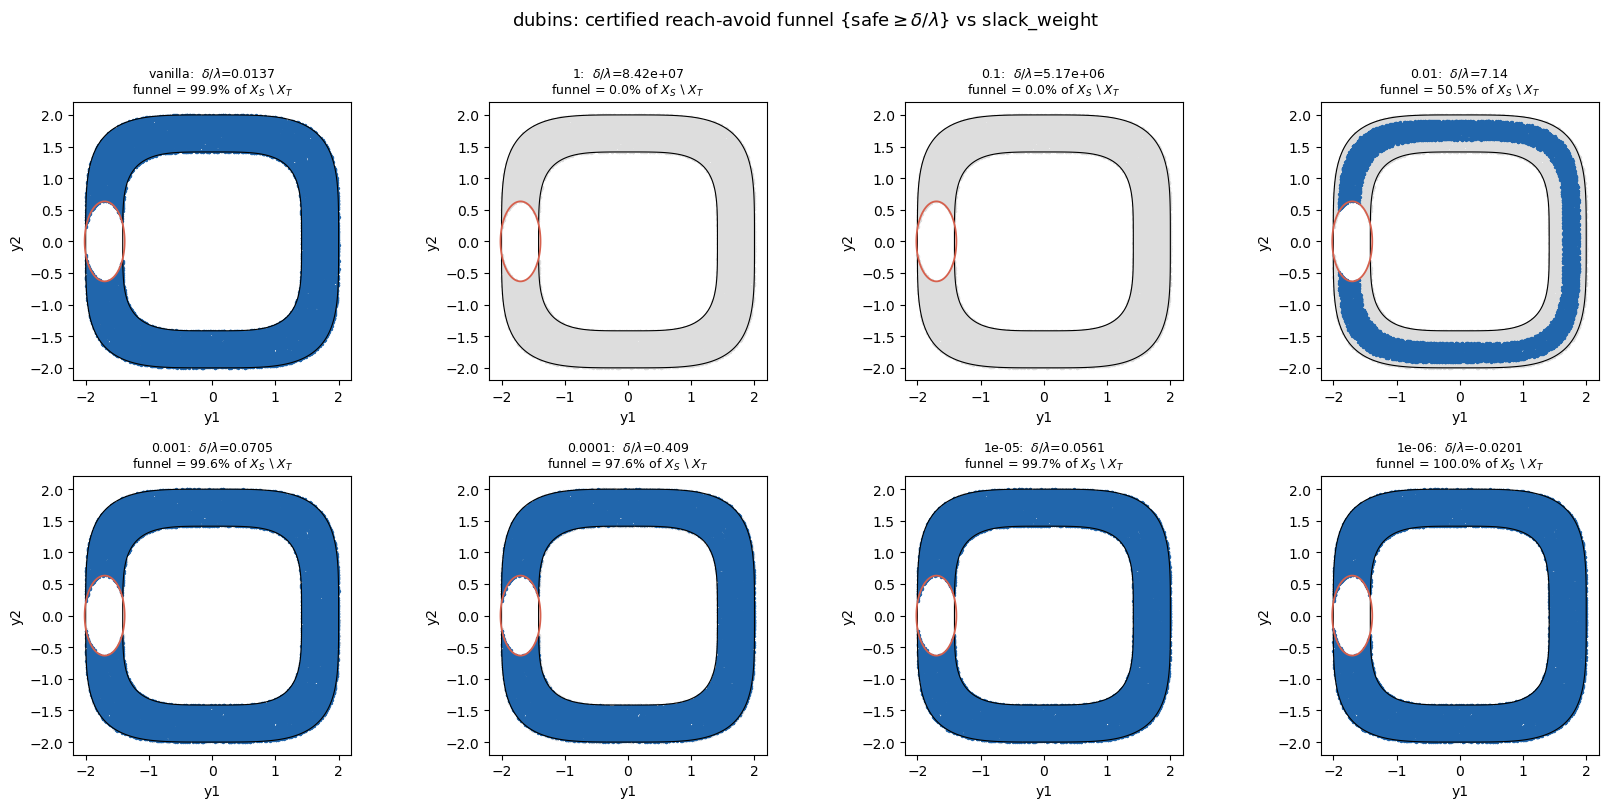

In [3]:
# one panel per row (vanilla + each slack_weight); dense points coloured by funnel membership
sub = rng.choice(Yin.shape[1], size=min(25_000, Yin.shape[1]), replace=False)
ncol = 4
nrow = int(np.ceil(len(df) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 4.0 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, (_, r) in zip(axes, df.iterrows()):
    tau = float(r["delta_over_lambda"])
    inside = safe_in[sub] >= tau
    frac = 100.0 * float(np.mean(safe_in >= tau))
    ax.scatter(Yin[0, sub][~inside], Yin[1, sub][~inside], s=2, c="#dddddd")
    ax.scatter(Yin[0, sub][inside], Yin[1, sub][inside], s=2, c="#2166ac")
    ax.contour(G1, G2, Zs, levels=[0], colors="k", linewidths=0.8)
    ax.contour(G1, G2, Zt, levels=[0], colors="#d6604d", linewidths=1.3)
    ax.set_aspect("equal")
    ax.set_xlim(LO, HI)
    ax.set_ylim(LO, HI)
    ax.set_xlabel("y1")
    ax.set_ylabel("y2")
    ax.set_title(
        f"{r['label']}:  "
        + r"$\delta/\lambda$="
        + f"{tau:.3g}\nfunnel = {frac:.1f}% of "
        + r"$X_S\setminus X_T$",
        fontsize=9,
    )
for ax in axes[len(df) :]:
    ax.axis("off")
fig.suptitle(
    r"dubins: certified reach-avoid funnel $\{$safe$\geq\delta/\lambda\}$ vs slack_weight",
    y=1.005,
    fontsize=13,
)
fig.tight_layout()
fig.savefig(
    os.path.join(DATA, "slack_weight_funnel_grid_dubins.png"),
    dpi=120,
    bbox_inches="tight",
)
plt.show()

## §4 — Funnel fraction and $\delta/\lambda$ vs `slack_weight`


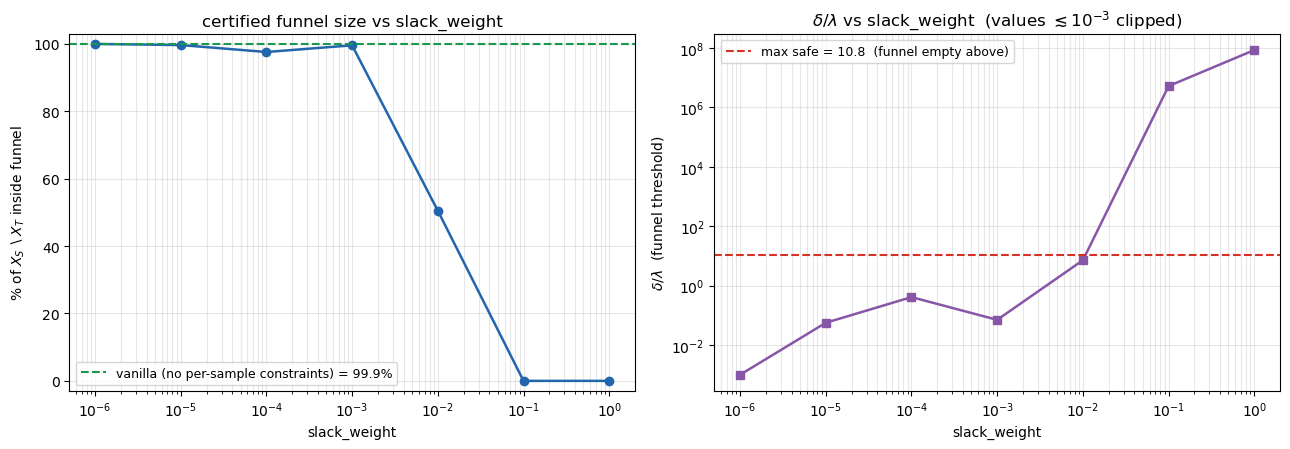

In [4]:
wmask = ~df["slack_weight"].isna().values
ws = df["slack_weight"].values[wmask]
order = np.argsort(ws)
ws_s = ws[order]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))
# left: funnel fraction vs slack_weight
axL.semilogx(ws_s, df["funnel_pct"].values[wmask][order], "o-", color="#2166ac", lw=1.8)
van = df[df["slack_weight"].isna()]
if len(van):
    axL.axhline(
        float(van["funnel_pct"].iloc[0]),
        color="#1a9850",
        ls="--",
        lw=1.5,
        label=f"vanilla (no per-sample constraints) = {float(van['funnel_pct'].iloc[0]):.1f}%",
    )
axL.set_xlabel("slack_weight")
axL.set_ylabel(r"% of $X_S\setminus X_T$ inside funnel")
axL.set_ylim(-3, 103)
axL.grid(True, which="both", alpha=0.3)
axL.legend(fontsize=9)
axL.set_title("certified funnel size vs slack_weight")
# right: delta/lambda vs slack_weight, with the empty-set threshold
tau_disp = np.clip(
    df["delta_over_lambda"].values[wmask][order], 1e-3, None
)  # clip ~0/neg for log axis
axR.loglog(ws_s, tau_disp, "s-", color="#8856a7", lw=1.8)
axR.axhline(
    safe_max,
    color="#d73027",
    ls="--",
    lw=1.5,
    label=f"max safe = {safe_max:.3g}  (funnel empty above)",
)
axR.set_xlabel("slack_weight")
axR.set_ylabel(r"$\delta/\lambda$  (funnel threshold)")
axR.grid(True, which="both", alpha=0.3)
axR.legend(fontsize=9)
axR.set_title(r"$\delta/\lambda$ vs slack_weight  (values $\lesssim10^{-3}$ clipped)")
fig.tight_layout()
fig.savefig(
    os.path.join(DATA, "slack_weight_funnel_curves_dubins.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §5 — Slacks per configuration

The per-sample control-bound violation is essentially **weight-invariant** (the max slack is
nearly constant across `slack_weight`); the weight only shifts the infeasibility between
$\delta$ and the slack sum, not the achievable control violation itself.


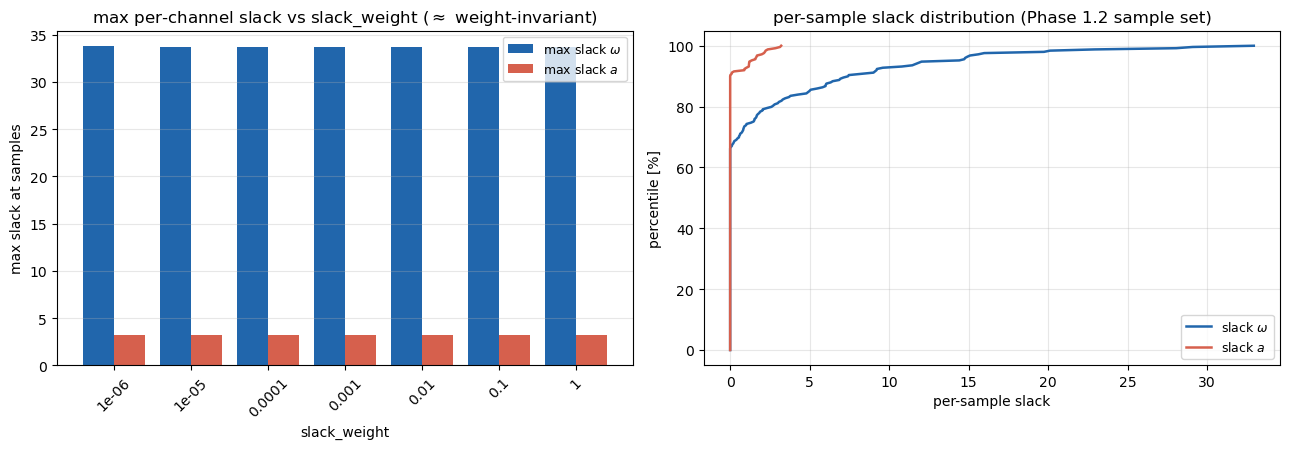

In [5]:
wmask = ~df["slack_weight"].isna().values
ws = df["slack_weight"].values[wmask]
order = np.argsort(ws)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))
# left: max slack per channel vs slack_weight
xpos = np.arange(int(wmask.sum()))
axL.bar(
    xpos - 0.2,
    df["slack1_max"].values[wmask][order],
    0.4,
    label=r"max slack $\omega$",
    color="#2166ac",
)
axL.bar(
    xpos + 0.2,
    df["slack2_max"].values[wmask][order],
    0.4,
    label=r"max slack $a$",
    color="#d6604d",
)
axL.set_xticks(xpos)
axL.set_xticklabels([f"{w:g}" for w in ws[order]], rotation=45)
axL.set_xlabel("slack_weight")
axL.set_ylabel("max slack at samples")
axL.legend(fontsize=9)
axL.grid(True, axis="y", alpha=0.3)
axL.set_title(r"max per-channel slack vs slack_weight ($\approx$ weight-invariant)")
# right: representative per-sample slack distribution (Phase 1.2 sample set)
ps_path = os.path.join(DATA, "slack_persample_dubins.csv")
if os.path.exists(ps_path):
    ps = pd.read_csv(ps_path)
    for col, c, lab in [
        ("slack1", "#2166ac", r"$\omega$"),
        ("slack2", "#d6604d", "$a$"),
    ]:
        s = np.sort(ps[col].values)
        axR.plot(s, np.linspace(0, 100, s.size), lw=1.8, color=c, label=f"slack {lab}")
    axR.set_xlabel("per-sample slack")
    axR.set_ylabel("percentile [%]")
    axR.legend(fontsize=9)
    axR.grid(True, alpha=0.3)
    axR.set_title("per-sample slack distribution (Phase 1.2 sample set)")
else:
    axR.axis("off")
fig.tight_layout()
fig.savefig(
    os.path.join(DATA, "slack_weight_slacks_dubins.png"), dpi=130, bbox_inches="tight"
)
plt.show()

## §6 — Takeaways

- The certified reach-avoid funnel is $\{\mathrm{safe}\ge\delta/\lambda\}$; it is **empty**
  once $\delta/\lambda>\max_{\mathcal X_S\setminus\mathcal X_T}\mathrm{safe}\approx 10.8$.
- At the Phase 1.2 weight (and any `slack_weight`$\ge 0.1$): $\delta/\lambda\sim10^{6}$–$10^{8}$
  $\Rightarrow$ **empty funnel** — the $k_1$ has no certified reach-avoid set. Only
  `slack_weight`$\lesssim0.01$ drops $\delta$ to the certificate-LMI floor so the funnel
  becomes non-empty ($\approx$ vanilla for $\le10^{-3}$).
- **No free lunch:** the max slack stays $\approx 33.7\,(\omega)\,/\,3.2\,(a)$ regardless of
  weight — the control-bound violation ($|u_\omega|\approx ub+34$) is intrinsic. `slack_weight`
  only moves that cost between $\delta$ (→ empty funnel) and the slacks (→ violated bounds).
  A non-empty certified funnel and respected input bounds **cannot both hold**.
